In [21]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
np.set_printoptions(threshold=np.inf)


In [22]:
df=pd.read_csv("../DataFrames/NYC_Central_Park_weather_1869-2022.csv")
df['DATE']=pd.to_datetime(df['DATE'])
df["DATE"] = df["DATE"].dt.strftime("%m-%d-%Y")
df['DATE']=pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)



In [ ]:
df['Temp']=(df["TMAX"]+df['TMIN'])/2
temp=df['Temp']
#print(temp.isna().sum())
temp = temp.ffill()
#print(temp.isna().sum())
#print(temp.head())
#temp.plot(figsize=(18, 6))
#print(temp[-60:])

In [24]:
def df_to_array(df, window_size):
    df_as_np=df.to_numpy()
    #print(df_as_np)
    X=[]
    y=[]
    for i in range(len(df_as_np)-window_size):
        row=[[a] for a in df_as_np[i:i+window_size]]
        X.append(row)
        label=df_as_np[i+window_size]
        y.append(label)
    return np.array(X), np.array(y)

WINDOW_SIZE=60
X, y =df_to_array(temp, WINDOW_SIZE)
#X.shape, y.shape
print(temp.shape)


(56245,)


In [25]:
X_train, y_train=X[:46000], y[:46000]
X_val, y_val=X[46000:51150], y[46000:51150]
X_test, y_test=X[51150:], y[51150:]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((46000, 60, 1), (46000,), (5150, 60, 1), (5150,), (5035, 60, 1), (5035,))

In [26]:
from tensorflow.keras.models import Sequential              #to
from tensorflow.keras.layers import *                       #to 
from tensorflow.keras.callbacks import ModelCheckpoint      #to save the model that does best on validations
from tensorflow.keras.losses import MeanSquaredError        # to 
from tensorflow.keras.metrics import RootMeanSquaredError   # sqrt of the errror
from tensorflow.keras.optimizers import Adam

In [27]:
model1=Sequential()                                 #Creates a neural network 
model1.add(InputLayer((WINDOW_SIZE, 1)))            #Tells the models teh shape on one training example
model1.add(LSTM(64))                                
model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))
model1.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
cp=ModelCheckpoint('model1.keras', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [29]:
model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, callbacks=[cp])

Epoch 1/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 1363.4471 - root_mean_squared_error: 36.9249 - val_loss: 427.3682 - val_root_mean_squared_error: 20.6729
Epoch 2/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 172.6855 - root_mean_squared_error: 13.1410 - val_loss: 61.7453 - val_root_mean_squared_error: 7.8578
Epoch 3/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - loss: 41.7695 - root_mean_squared_error: 6.4629 - val_loss: 32.4824 - val_root_mean_squared_error: 5.6993
Epoch 4/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - loss: 32.4114 - root_mean_squared_error: 5.6931 - val_loss: 29.4328 - val_root_mean_squared_error: 5.4252
Epoch 5/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 30.8064 - root_mean_squared_error: 5.5503 - val_loss: 28.6188 - val_root_mean_squared_error: 5.3497
Epoch 6/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 30.2651 - root_mean_squared_error: 5.5014 - val_loss: 28.4180 - val_root_mean_squared_error: 5.3309
Epoch 7/3

In [30]:
from tensorflow.keras.models import load_model
model1=load_model('model1.keras')

In [31]:
train_predicions=model1.predict(X_train).flatten()
train_results=pd.DataFrame(data={'Train Predictions': train_predicions, 'Actuals': y_train})
train_results

1438/1438 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step


,Train Predictions,Actuals
0,21.194284,27.5
1,33.959885,35.5
2,34.848732,31.5
3,30.606541,23.0
4,24.253397,28.0
...,...,...
45995,35.171631,18.0
45996,18.576588,13.0
45997,21.306387,20.0
45998,26.004408,23.0


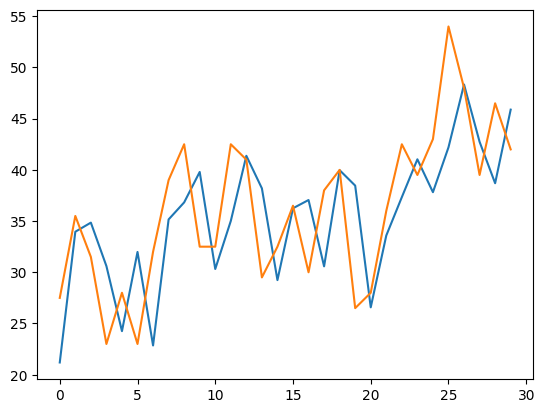

In [32]:
plt.plot(train_results["Train Predictions"][:30], label='Train Predictions')
plt.plot(train_results["Actuals"][:30], label='Real Data')


In [33]:
val_predicions=model1.predict(X_val).flatten()
val_results=pd.DataFrame(data={'Validation Predictions': val_predicions, 'Actuals': y_val})
val_results


161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


,Validation Predictions,Actuals
0,25.501348,33.5
1,34.850258,38.0
2,35.143173,19.5
3,17.559793,20.0
4,27.162542,27.0
...,...,...
5145,37.189461,33.5
5146,37.693604,41.5
5147,43.812489,46.5
5148,45.885925,43.5


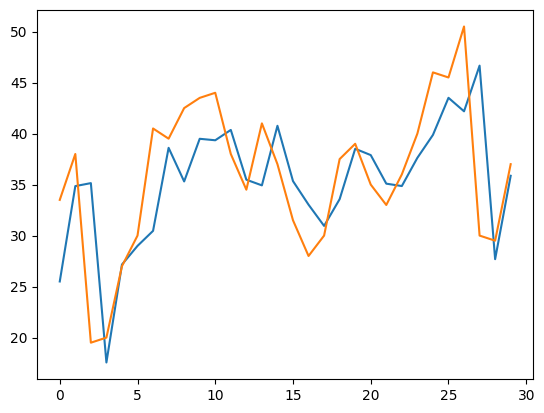

In [34]:
plt.plot(val_results["Validation Predictions"][:30], label='Validation Predictions')
plt.plot(val_results["Actuals"][:30], label="Real Data")

In [35]:
test_predictions=model1.predict(X_test).flatten()
test_results=pd.DataFrame(data={'Test Predictions': test_predictions, 'Actuals': y_test})
test_results


158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


,Test Predictions,Actuals
0,45.961205,52.5
1,50.411175,47.5
2,45.859436,39.5
3,41.112022,40.0
4,43.223190,44.5
...,...,...
5030,15.459696,21.0
5031,31.684587,23.5
5032,24.966585,32.0
5033,35.968449,40.0


Text(0.5, 1.0, '2022 Test Predictions vs Real Data')

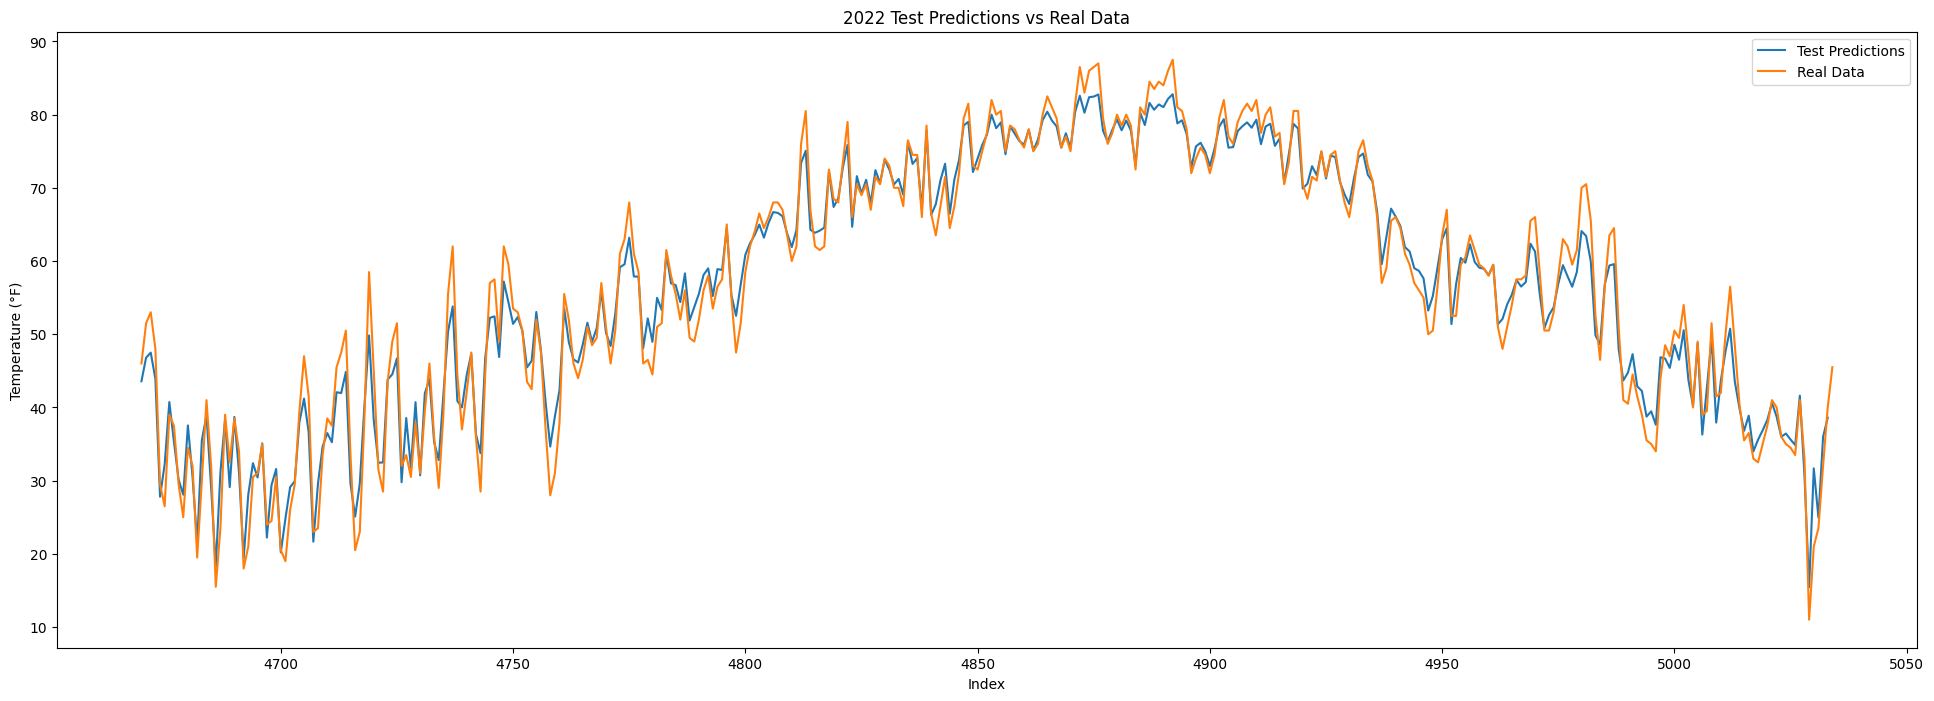

In [36]:
plt.figure(figsize=(24, 8))
preds = pd.Series(test_results["Test Predictions"][-365:]).shift(-1)
plt.plot(preds, label='Test Predictions')
plt.plot(test_results["Actuals"][-365:], label='Real Data')
plt.legend()
plt.xlabel("Index")
plt.ylabel('Temperature (\u00B0F)')
plt.title('2022 Test Predictions vs Real Data')


Average Error:  -0.03660528700069969


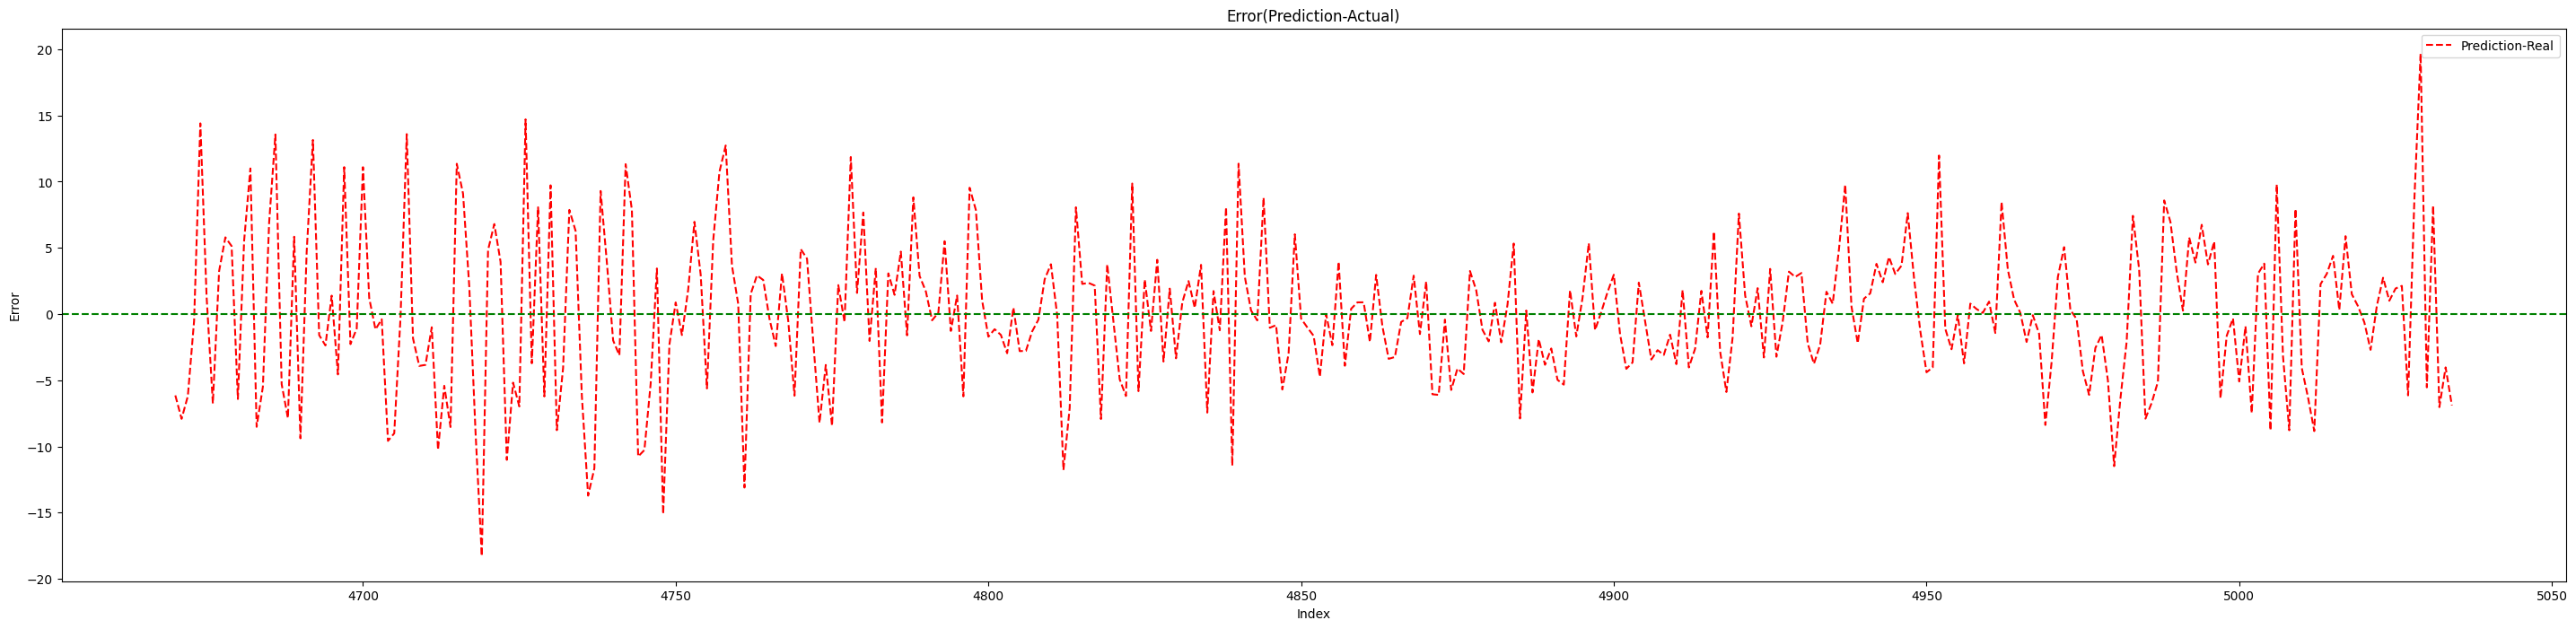

In [37]:
errors=test_results['Test Predictions']-test_results['Actuals']
#print(errors[:20])
avg_error=np.mean(errors)
print("Average Error: ", avg_error)
plt.figure(figsize=(36, 8))
plt.plot(errors[-365:], linestyle='dashed', color='red', label='Prediction-Real')
plt.axhline(0, linestyle='--', color='green')
plt.xlabel('Index')
plt.ylabel('Error')
plt.title('Error(Prediction-Actual)')
plt.legend()

In [38]:
next_100_years=pd.date_range(
    start="01-01-2023",
    periods=36500,
    freq='D'
)
print(next_100_years)

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2122-11-28', '2122-11-29', '2122-11-30', '2122-12-01',
               '2122-12-02', '2122-12-03', '2122-12-04', '2122-12-05',
               '2122-12-06', '2122-12-07'],
              dtype='datetime64[us]', length=36500, freq='D')


In [39]:
future_predictions=temp.values[-60:].tolist()
for i in range(365):
    currentWindow=np.array([[[a] for a in future_predictions[-WINDOW_SIZE:]]])
    prediction=model1.predict(currentWindow, verbose=0)
    future_predictions.append(prediction[0][0])


56245
425
-55820
[38.56333923 37.26578522 36.75868607 36.44469452 36.16635513 35.84487152
 35.49220657 35.16967392 34.94091797 34.80170441 34.66543198 34.53246307
 34.53699875 34.67625427 34.76207352 34.78459167 34.89131546 35.06304932
 35.2016716  35.17064667 34.92954636 34.6004982  34.37085342 34.25476837
 34.18873596 34.17247772 34.21232605 34.37669373 34.59469604 34.69817352
 34.8575058  34.89999771 34.81695938 34.88108063 34.91064072 34.88401413
 35.03061295 35.55713654 36.28833008 36.94443893 37.4233551  37.83778
 38.12765503 38.25235748 38.32025909 38.45982361 38.78730774 39.25601959
 39.71272278 40.12296295 40.51234055 40.94792938 41.80014801 42.86774063
 43.39747238 43.44810867 42.95241165 42.37374878 42.25300217 42.75028992
 43.51344681 44.2379837  44.88531494 45.49604034 46.09363937 46.68262482
 47.25856018 47.8155098  48.35040283 48.864151   49.35971451 49.83943558
 50.30518341 50.76056671 51.21014404 51.6564827  52.10057831 52.54426956
 52.99010468 53.43965149 53.89205933 

Text(0.5, 1.0, '365 Day Forecast')

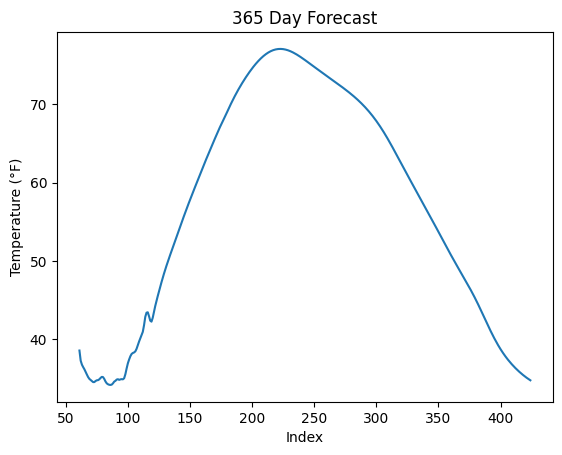

In [40]:
print(len(temp))
print(len(future_predictions))
print(len(future_predictions)-len(temp))

future_predictions = np.array(future_predictions).reshape(-1)
new_Year=pd.DataFrame({'values': future_predictions})
plt.plot(new_Year['values'][61:])
print(future_predictions[61:])
plt.xlabel('Index')
plt.ylabel('Temperature (\u00B0F)')
plt.title('365 Day Forecast')

In [41]:
mae=mean_absolute_error(y_test.flatten(), test_predictions.flatten())
print("Mean Absolute Error= ", mae)

Mean Absolute Error=  4.08067696863987
